In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
import torchaudio
import numpy as np
print(torchaudio.__version__)
import matplotlib.pyplot as plt

2.6.0+cu124
CUDA available: True
2.6.0+cu124


In [3]:
def sin_wav(freq, Fs, duration):
    t = torch.linspace(0,duration,int(Fs*duration))
    return torch.sin(t*2*np.pi*freq)

def make_phase(freq, Fs, duration):
    # returns the phase ramp tensor before sin is applied
    t = torch.linspace(0, duration, int(Fs*duration))
    return t * (2*np.pi) * freq
def apply_phase_mod(phase, modulation):
    # adds modulation to phase and applies sin, returns audio signal
    modulated_phase = phase+modulation
    return torch.sin(modulated_phase)

In [4]:
def operator(freq, Fs, duration, level, modulation=None):
    # returns operator output tensor [n_samples]
    self_phase = make_phase(freq, Fs, duration)
    if modulation is None:
        modulation = torch.zeros_like(self_phase)
    return apply_phase_mod(self_phase,modulation) * level
    
    

In [17]:
def fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, Fs, duration):
    # compute details of each operator
    num_samples = int( Fs*duration )
    num_ops = 4
    
    t = torch.linspace(0, duration, num_samples)
    freqs = f0 * ratios
    phase = 2 * torch.pi * freqs.unsqueeze(1) * t.unsqueeze(0)
    
    # compute operator signals
    raw = torch.sin(phase) * levels.unsqueeze(1) # [4, num_samples]
    feedback = torch.roll(raw, 1, dims=1) * torch.diag(mod_matrix).unsqueeze(1)
    feedback[:,0] = 0.0
    
    # compute modulated phase
    # for i in range num_ops:
    #     for j in range num_ops:
    #         if i == j:
    #             phase_mod[i] += feedback[i, :]
    #         else:
    #             phase_mod[i] += mod_matrix[i][j] * raw[j]
    
    phase_mod = torch.matmul(mod_matrix, raw)
    # apply the feedback values
    diag = torch.diag(mod_matrix)
    phase_mod -= diag.unsqueeze(1) * raw
    phase_mod += diag.unsqueeze(1) * feedback
    
    # recompute operator outputs with modulation
    op_out = torch.sin(phase+phase_mod) * levels.unsqueeze(1)
    
    # normalize carrier outputs
    cw_normalized = carrier_weights / (carrier_weights.sum() + 1e-8)
    # return audio out
    audio_out = torch.zeros(num_samples)
    # for i in range num_ops
    #     audio_out += op_out[i, :] * carrier_weights[i]
    audio_out = (op_out * cw_normalized.unsqueeze(1)).sum(dim=0)
    return audio_out
        
    

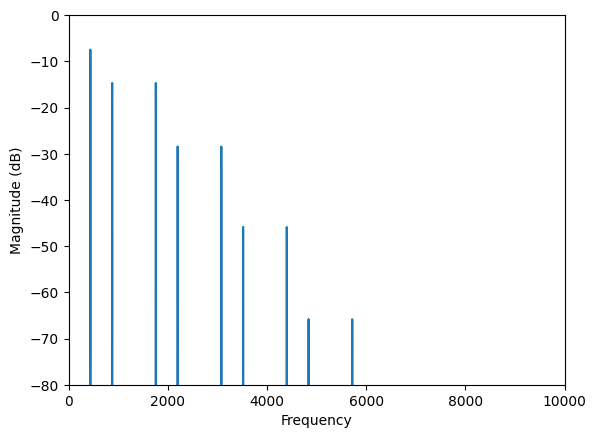

 Frequency (Hz)  Magnitude (dB)
--------------------------------
          440.0             0.0
          880.0            -7.2
         1760.0            -7.2
         2200.0           -21.0
         3080.0           -21.0
         3520.0           -38.5
         4400.0           -38.5


In [21]:
f0 = 440.0
ratios = torch.tensor([3.0, 1.0, 1.0, 1.0])
levels = torch.tensor([0.8, 1.0, 0.0, 0.0])
mod_matrix = torch.zeros(4,4)
mod_matrix[1][0] = 1.0
carrier_weights = torch.tensor([0.0, 1.0, 0.0, 0.0])
audio = fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, 44100, 1.0)
plt.magnitude_spectrum(audio.numpy(), Fs=44100, scale='dB')
plt.xlim(0, 10000)
plt.ylim(-80, 0)
plt.show() 
# compute FFT
fft = torch.fft.rfft(audio)
magnitudes = fft.abs().numpy()
freqs = np.fft.rfftfreq(len(audio), d=1/44100)

# find peaks above a threshold
threshold_db = -40  # only show peaks above -40dB
max_mag = magnitudes.max()
threshold_linear = max_mag * 10**(threshold_db/20)

peak_indices = np.where(magnitudes > threshold_linear)[0]

# find local maxima only (ignore neighbours)
from scipy.signal import find_peaks
peaks, _ = find_peaks(magnitudes, height=threshold_linear, distance=10)

print(f"{'Frequency (Hz)':>15} {'Magnitude (dB)':>15}")
print("-" * 32)
for p in peaks:
    db = 20 * np.log10(magnitudes[p] / max_mag)
    print(f"{freqs[p]:>15.1f} {db:>15.1f}")